# `1st Order SHAP` Analysis

## Purpose: 

VERY LONG list of analyses done to better understand `1st Order SHAP` values.

`1st Order` refers to calculating `SHAP` values in the canonical way that assigns individual feature importances per row and does not look at any feature-feature interactions (this is covered in the `2nd Order SHAP` analysis).  

## Packages, Options and Class Instantiation

In [1]:
import pandas as pd
pd.set_option('display.max_rows', 1000000)
pd.set_option('display.max_columns', 1000000)
pd.set_option('display.max_colwidth', 10000000)

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import polars as pl 

_=pl.Config.set_tbl_cols(100000)
_=pl.Config.set_tbl_rows(10000)
_=pl.Config.set_tbl_width_chars(10000)
_=pl.Config.set_fmt_str_lengths(10000)

%load_ext autoreload 
%autoreload 2

import importlib

SHAP_analysis_class = getattr(
    importlib.import_module("1_first_order_shap_investigator"), 
    "FirstOrderShapInvestigator"
)

data_modes = ["All-Data", "Unique-Binding"]
binding_modes = ["Bound-Only", "NOT-Bound-Only"]
FDR_cutoffs = [0.1, 0.05]

investigator = SHAP_analysis_class()
investigator.hash_metadata

/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_first_order_SHAP_analysis/code/1_first_order_shap_investigator.py:7592: SyntaxWarning: invalid escape sequence '\m'
  axes[row_idx, 0].set_ylabel(f"$\mathbf{{{cell_line}}}$", fontsize=30, fontweight="bold", rotation=0, ha="right", va="center", labelpad=20)
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_first_order_SHAP_analysis/code/1_first_order_shap_investigator.py:7595: SyntaxWarning: invalid escape sequence '\m'
  axes[0, col_idx].set_title(f"$\mathbf{{{condition}}}$", fontsize=30, fontweight="bold", pad=20, ha="center", va="bottom")
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_first_order_SHAP_analysis/code/1_first_order_shap_investigator.py:7618: SyntaxWarning: invalid escape sequence '\m'
  f"$\mathbf{{{kd_rbp}}}$ Knockdown\n\n"
2026-03-27 12:45:01.514 | SUCCESS  | 1_f

,hash,name,seed,cell_line,n_jobs,objective,eval_metric,n_estimators,early_stopping_rounds,learning_rate,max_depth,min_child_weight,gamma,subsample,colsample_bytree,reg_alpha,reg_lambda,shap_expected_value,holdout_r2_score,l1_ratio,alpha
0,ajtg,XGBRegressor,17,HepG2,-1.0,reg:logistic,"['rmse', 'logloss']",100000.0,100.0,0.10,5.0,100.0,0.5,0.75,0.75,0.0,0.5,1.592665,0.292552,NaN,NaN
1,btjy,XGBRegressor,17,HepG2,-1.0,reg:logistic,"['rmse', 'logloss']",100000.0,100.0,0.10,5.0,100.0,0.5,0.75,0.75,0.2,10.0,1.592324,0.291689,NaN,NaN
2,gufp,XGBRegressor,17,HepG2,-1.0,reg:logistic,"['rmse', 'logloss']",100000.0,100.0,0.10,5.0,100.0,0.5,0.75,0.75,0.0,10.0,1.592609,0.297097,NaN,NaN
3,jmhq,XGBRegressor,17,HepG2,-1.0,reg:logistic,"['rmse', 'logloss']",100000.0,100.0,0.10,5.0,100.0,0.5,0.75,0.75,1.0,5.0,1.592733,0.293902,NaN,NaN
4,juwg,XGBRegressor,17,HepG2,-1.0,reg:logistic,"['rmse', 'logloss']",100000.0,100.0,0.10,5.0,100.0,0.5,0.75,0.75,0.8,0.5,1.592432,0.294003,NaN,NaN
5,kzbv,XGBRegressor,17,K562,-1.0,reg:logistic,"['rmse', 'logloss']",100000.0,100.0,0.01,5.0,50.0,1.0,0.75,0.25,0.0,10.0,1.622466,0.277924,NaN,NaN
6,mzdv,XGBRegressor,17,K562,-1.0,reg:logistic,"['rmse', 'logloss']",100000.0,100.0,0.01,5.0,50.0,1.0,0.75,0.25,1.0,10.0,1.622553,0.275066,NaN,NaN
7,niwy,XGBRegressor,17,K562,-1.0,reg:logistic,"['rmse', 'logloss']",100000.0,100.0,0.01,5.0,50.0,1.0,0.75,0.25,1.0,5.0,1.622543,0.279251,NaN,NaN
8,nuyh,XGBRegressor,17,K562,-1.0,reg:logistic,"['rmse', 'logloss']",100000.0,100.0,0.01,5.0,50.0,1.0,0.75,0.25,0.8,0.1,1.622497,0.277303,NaN,NaN
9,oodr,XGBRegressor,17,K562,-1.0,reg:logistic,"['rmse', 'logloss']",100000.0,100.0,0.01,5.0,50.0,1.0,0.75,0.25,0.0,1.0,1.622581,0.276435,NaN,NaN


<h1 style="color: teal; font-weight: bold; font-size: 48px;">Data QC + Cache Creation</h1>

## Check for Nulls in `SHAP`/Binding

In [ ]:
investigator.run_data_quality_assertions()

## Assert `SHAP` additivity


In [ ]:
investigator.assert_SHAP_additivity()

## Check no `Local SHAP` variance per binding pattern

In [ ]:
table = investigator.check_no_SHAP_variance_per_binding_pattern()

table.sample(10)
table["num_unique_shap_rows"].value_counts()

## Create Final SHAP Cache

In [ ]:
investigator.load_final_SHAP_data(underlying_data="All-Data")

In [ ]:
for key in investigator.final_all_data_SHAP_data: 
    investigator.final_all_data_SHAP_data[key].shape
    investigator.final_all_data_SHAP_data[key].head()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Predicted vs Actual Plots & Performance</h1>

## `PSI`

In [ ]:
for mode in data_modes:

    investigator.plot_actual_vs_predicted_for_best_models(underlying_data = mode)

## `DeltaPSI`

In [ ]:
table = investigator.plot_actual_vs_predicted_for_best_models(underlying_data = "Delta")

## `KDE` Plot 

In [ ]:
investigator.plot_actual_vs_predicted_as_kde(bw_adjust=1.0, levels=30)

## Create Model Performance Tables

In [ ]:
investigator.create_model_average_performance_table()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">View Feature Distribution of Local SHAP</h1>

In [ ]:
# investigator.plot_local_SHAP_distribution_per_feature_as_mp4()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Global SHAP Across Models and for Average Local SHAP</h1>

In [ ]:
tables = investigator.calculate_global_SHAP(mode="5_dfs", binding_unique="All-Data")

for key in tables: 
    key
    tables[key]

In [ ]:
investigator.plot_global_SHAP(mode="5_dfs", binding_unique="All-Data")

In [ ]:
tables = investigator.calculate_global_SHAP(mode="5_dfs_average", binding_unique="All-Data")

for key in tables: 
    key
    tables[key]

In [ ]:
investigator.plot_global_SHAP(mode="5_dfs_average", binding_unique="All-Data")

In [ ]:
investigator.plot_global_SHAP(mode="5_dfs_average", binding_unique="Unique-Binding")

In [ ]:
tables = investigator.plot_global_SHAP_mean_vs_variance(mode="5_dfs", binding_unique="Unique-Binding")

for key in tables: 
    key 
    tables[key].head()


In [ ]:
investigator.plot_global_SHAP_coefficient_of_variation(mode='5_dfs', binding_unique="Unique-Binding")

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Local SHAP Variance Analysis</h1>

In [ ]:
investigator.plot_SHAP_CV()

In [ ]:
investigator.plot_SHAP_std()

In [ ]:
investigator.plot_local_SHAP_mean_vs_variance()

In [ ]:
for mode in binding_modes: 
    mode
    investigator.calculate_local_SHAP_mean_vs_variance_deciles(mode=mode)

<h1 style="color: teal; font-weight: bold; font-size: 48px;">ElasticNet</h1>


In [ ]:
elasticnet = investigator.load_elasticnet_coefficients()

for key in elasticnet: 
    key 
    elasticnet[key]["coefficients"].head()

In [ ]:
investigator.plot_elasticnet_coefficients()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Position 3 + 4 Significance in Global SHAP/ElasticNet</h1>


In [ ]:
investigator.check_position_3_and_4_significance_for_global_SHAP_and_elasticnet()

In [ ]:
investigator.show_3_and_4_significance_for_bound_global_SHAP()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Is Position 3/4 Activator-Like and Other Positions Repressor-Like?</h1>

In [ ]:
investigator.is_position_3_4_activating_and_others_repressing()

In [ ]:
investigator.plot_position_signed_average_barplot()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Make Global SHAP Plots with Variations</h1>

# Variations: 
* Unique Binding Patterns 
* Feature is bound
* Feature is NOT bound
* Feature is NOT bound in CONTROL
* Feature is NOT bound in ROW W/ RBP KD AT ANY POSITION
* Feature is NOT bound in ROW W/ RBP KD AT SPECIFIC POSITION
* Use signed (not absolute value) summation of Local SHAP
* `Log-Odds` signed summation of Bound Only Local SHAP

## Unique Binding

In [ ]:
investigator.plot_global_SHAP(mode="5_dfs_average", binding_unique="Unique-Binding")

In [ ]:
investigator.plot_global_SHAP_between_unique_binding_and_all_data()

## Bound Only 

In [ ]:
tables = investigator.calculate_specialized_global_SHAP(mode="Bound-Only", condition=None, underlying_data="Unique-Binding")
for key in tables: 
    tables[key]

In [ ]:
investigator.plot_global_SHAP(mode="Bound-Only", binding_unique="All-Data")

In [ ]:
investigator.plot_global_SHAP(mode="Bound-Only", binding_unique="Unique-Binding")

## NOT Bound Only

In [ ]:
tables = investigator.calculate_specialized_global_SHAP(mode="NOT-Bound-Only", condition=None, underlying_data="Unique-Binding")
for key in tables: 
    tables[key]

In [ ]:
investigator.plot_global_SHAP(mode="NOT-Bound-Only", binding_unique="Unique-Binding")

In [ ]:
investigator.plot_specialized_vs_regular_global_SHAP(underlying_data="Unique-Binding")

## NOT Bound Only Variations

In [ ]:
tables = investigator.calculate_specialized_global_SHAP(mode="NOT-Bound-Only", condition="CTRL")
for key in tables: 
    tables[key]

In [ ]:
investigator.plot_global_SHAP(mode="NOT-Bound-Only-CTRL", binding_unique="All-Data")

In [ ]:
tables = investigator.calculate_specialized_global_SHAP(mode="NOT-Bound-Only", condition="RBP_KD")
for key in tables: 
    tables[key]

In [ ]:
investigator.plot_global_SHAP(mode="NOT-Bound-Only-RBP_KD", binding_unique="All-Data")

In [ ]:
tables = investigator.calculate_specialized_global_SHAP(mode="NOT-Bound-Only", condition="RBP_KD_at_position")
for key in tables: 
    tables[key]

In [ ]:
investigator.plot_global_SHAP(mode="NOT-Bound-Only-RBP_KD_at_position", binding_unique="All-Data")

## Signed Global SHAP

In [ ]:
for mode in binding_modes: 
    
    mode = "Signed-Local-SHAP-Mean-" + mode
    
    tables = investigator.calculate_specialized_global_SHAP(mode=mode, condition=None, underlying_data="Unique-Binding")
    for key in tables: 
        tables[key]

In [ ]:
for mode in binding_modes: 
    
    mode = "Signed-Local-SHAP-Mean-" + mode
    
    investigator.plot_global_SHAP(mode=mode, binding_unique="Unique-Binding")

In [ ]:
investigator.compare_bound_global_SHAP_and_signed_mean_bound_local_SHAP()

## Signed Global SHAP Vignette for Paper

In [ ]:
investigator.plot_signed_global_SHAP_row_min_and_max_vignette(binding_unique="Unique-Binding", top_n=10)

## Signed Global SHAP (Log-Odds)

In [ ]:
# tables = investigator.calculate_specialized_global_SHAP(mode="Signed-Local-SHAP-Mean-LOG_ODDS-Bound-Only", condition=None, underlying_data="Unique-Binding")

# for key in tables: 
#     tables[key]

In [ ]:
# investigator.plot_global_SHAP(mode="Signed-Local-SHAP-Mean-LOG_ODDS-Bound-Only", binding_unique="Unique-Binding")

In [ ]:
# investigator.compare_signed_mean_bound_local_SHAP_between_probability_and_log_odds_units()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Global SHAP across Binding Modes & Positional Vignettes</h1>


In [ ]:
investigator.plot_global_SHAP_distributions_across_binding_modes()

In [ ]:
investigator.plot_global_SHAP_examples_as_bar_plots(mode = "Bound-Only", underlying_data="Unique-Binding")

In [ ]:
investigator.plot_global_SHAP_examples_as_bar_plots(mode="Signed-Local-SHAP-Mean-Bound-Only", underlying_data="Unique-Binding")

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Local SHAP Sign Analysis</h1>

# Includes: 


* Percentage of local SHAP that is non-zero at different cutoffs
* Percentage of local SHAP positive/negative either when feature is bound or unbound
* Understanding activation and repression through custom metric

## % Non-Zero SHAP

In [ ]:
investigator.calculate_local_SHAP_percent_non_zero(mode="Unique-Binding").head()

In [ ]:
investigator.plot_local_SHAP_percent_non_zero()

## Negative & Positive Local SHAP

In [ ]:
investigator.calculate_percent_positive_and_negative_local_SHAP_per_feature(mode = "NOT-Bound-Only", underlying_data="Unique-Binding")
investigator.calculate_percent_positive_and_negative_local_SHAP_per_feature(mode = "Bound-Only", underlying_data="Unique-Binding")


In [ ]:
investigator.plot_percent_positive_and_negative_local_SHAP_per_feature(underlying_data="Unique-Binding")

## Custom Metric for Activation and Repression Behavioral Understanding

In [ ]:
for binding_mode in ["Bound-Only", "NOT-Bound-Only"]: 
    investigator.calculate_activator_repressor_behavior_score(binding_mode=binding_mode, underlying_data="Unique-Binding").head()

In [ ]:
investigator.plot_activator_repressor_behavior_score(underlying_data = "Unique-Binding")

In [ ]:
investigator.plot_activator_repressor_behavior_score_vs_percent_positive_and_negative(underlying_data="Unique-Binding")

<h1 style="color: red; font-weight: bold; font-size: 60px;">INCOMPLETE</h1>

<h1 style="color: teal; font-weight: bold; font-size: 48px;">SHAP for Zero Binding Rows</h1>

Looks at: 

* Heatmap of `NOT Bound` "`Global SHAP`" for rows of: 
    * Control
    * The KD of the RBP for that feature
    * That feature having in-silico knockdown 

<br>


* Heatmap of % of zero binding events that have "0" `Local SHAP`

<br>

In [ ]:
investigator.shap_for_zero_binding_features_by_condition()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Differential Splicing Events</h1>

### Focuses on: 

* RBP-specific: 
    * \# Significant Diff Events 
    * \# Significant Diff Events w/ RBP KD at **ANY** Position
* Feature-specific: 
    * \# Significant Diff Events w/ RBP KD at **SPECIFIC** Position

<br>

* `Fisher's Exact` test for association between binding and significant splicing


In [ ]:
investigator.create_feature_metric_summary_table()

In [ ]:
investigator.plot_differential_splicing_types()


In [ ]:
investigator.plot_differential_ranks()

In [ ]:
investigator.plot_differential_ratios()

In [ ]:
investigator.plot_matching_differential_ratios_scatterplot()

In [ ]:
for cutoff in FDR_cutoffs: 
    investigator.binding_vs_diff_events_fishers_association(FDR_threshold = cutoff)

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Metric w/ Regulatory Explanation</h1>

* `Global SHAP`
* `ElasticNet coefficients`
* `Total Binding`
* `# Differential Events`

In [ ]:
investigator.plot_feature_metric_summary_table()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Hacky, Quick, and Dirty Analysis</h1>

In [ ]:
investigator.hacky_not_bound_global_SHAP_by_number_binding()

In [ ]:
investigator.hacky_plot_bound_unbound_signed_local_SHAP_vs_PSI()

In [ ]:
investigator.hacky_plot_bound_unbound_all_data_vs_unique_binding_global_SHAP()

In [ ]:
investigator.hacky_explore_SHAP_in_PSI_units()

In [ ]:
investigator.hacky_check_shap_additivity()

In [ ]:
investigator.hacky_log_odds_test_data_dpsi_vs_local_shap_scatterplot()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Binding Sum Distribution</h1>

In [ ]:
investigator.plot_binding_sum_distribution()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Per Row: Local SHAP Values > Cutoff</h1>

In [ ]:
table = investigator.calculate_num_and_percent_bound_local_shap_greater_than_cutoff()

In [ ]:
table["K562"].head()

In [ ]:
investigator.plot_num_and_percent_bound_local_shap_greater_than_cutoff()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Choose Examples Showcasing Local SHAP and PSI Concordance</h1>


In [ ]:
investigator.plot_local_SHAP_vs_PSI(feature="AQR_4_shap", underlying_data="All-Data")

<h1 style="color: teal; font-weight: bold; font-size: 48px;">PSI Distributions by Binding Mode</h1>


In [ ]:
investigator.feature_PSI_distributions_by_binding(feature="IGF2BP1_3_binding")

In [ ]:
for seed in range(100, 1001, 100): 
    investigator.feature_PSI_distributions_by_binding(feature="IGF2BP1_3_binding", sampling_seed = seed)

<h1 style="color: teal; font-weight: bold; font-size: 48px;">SHAP Waterfall Plot</h1>


In [ ]:
# table = investigator.find_shap_waterfall_plot_examples()

# for key in table: 
    
#     key
#     tmp = table[key]
    
#     tmp.shape
#     pd.DataFrame(tmp["RBP_KD_Target"].sort_values().unique())
    
#     tmp

In [ ]:
investigator.find_shap_waterfall_plot_examples()

In [ ]:
investigator.plot_shap_waterfall_examples()

In [ ]:
investigator.final_all_data_SHAP_data["K562"].head()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Differential PSI and Local SHAP</h1>


# `Test` Data

In [ ]:
for cutoff in [1.0] + FDR_cutoffs: 
    
    investigator.plot_dpsi_vs_local_SHAP_for_test_data(
        FDR_threshold = cutoff, 
        plot_metric = "CTRL - KD Local SHAP"
    )

    investigator.plot_dpsi_vs_local_SHAP_for_test_data(
        FDR_threshold = cutoff, 
        plot_metric = "CTRL - KD Model Prediction (Probability)"
    )

In [ ]:
investigator.correlation_between_test_dpsi_and_local_SHAP()

In [ ]:
for only_candidate_features in [False, True]:  
    investigator.delta_local_SHAP_significant_vs_not_significant_by_pos_neg_dpsi_in_test(only_candidate_features = only_candidate_features)

In [ ]:
investigator.plot_feature_candidates_for_dpsi_vs_local_SHAP_in_test()

# `All Partitions`

In [ ]:
investigator.create_dpsi_vs_local_SHAP_for_all_partitions()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">CLASSIFICATION VIEW: Differential PSI and Local SHAP</h1>


In [ ]:
input_data_modes = ["test", "test candidate features"]

In [ ]:
for mode in input_data_modes: 
    investigator.create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign(
        across_thresholds = False, 
        data_mode = mode
    )

In [ ]:
for mode in input_data_modes: 
    investigator.create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign(
        across_thresholds = True,
        data_mode = mode
    )

In [ ]:
for mode in input_data_modes: 
    investigator.run_fishers_test_across_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign(
        data_mode = mode
    )

2026-03-27 12:45:02.405 | WARNING  | 1_first_order_shap_investigator:plot_dpsi_vs_local_SHAP_fishers_test_odds_ratios_as_barplot:9774 - "Test Candidate Features" are ignored and instead all features (i.e. "Test") are used




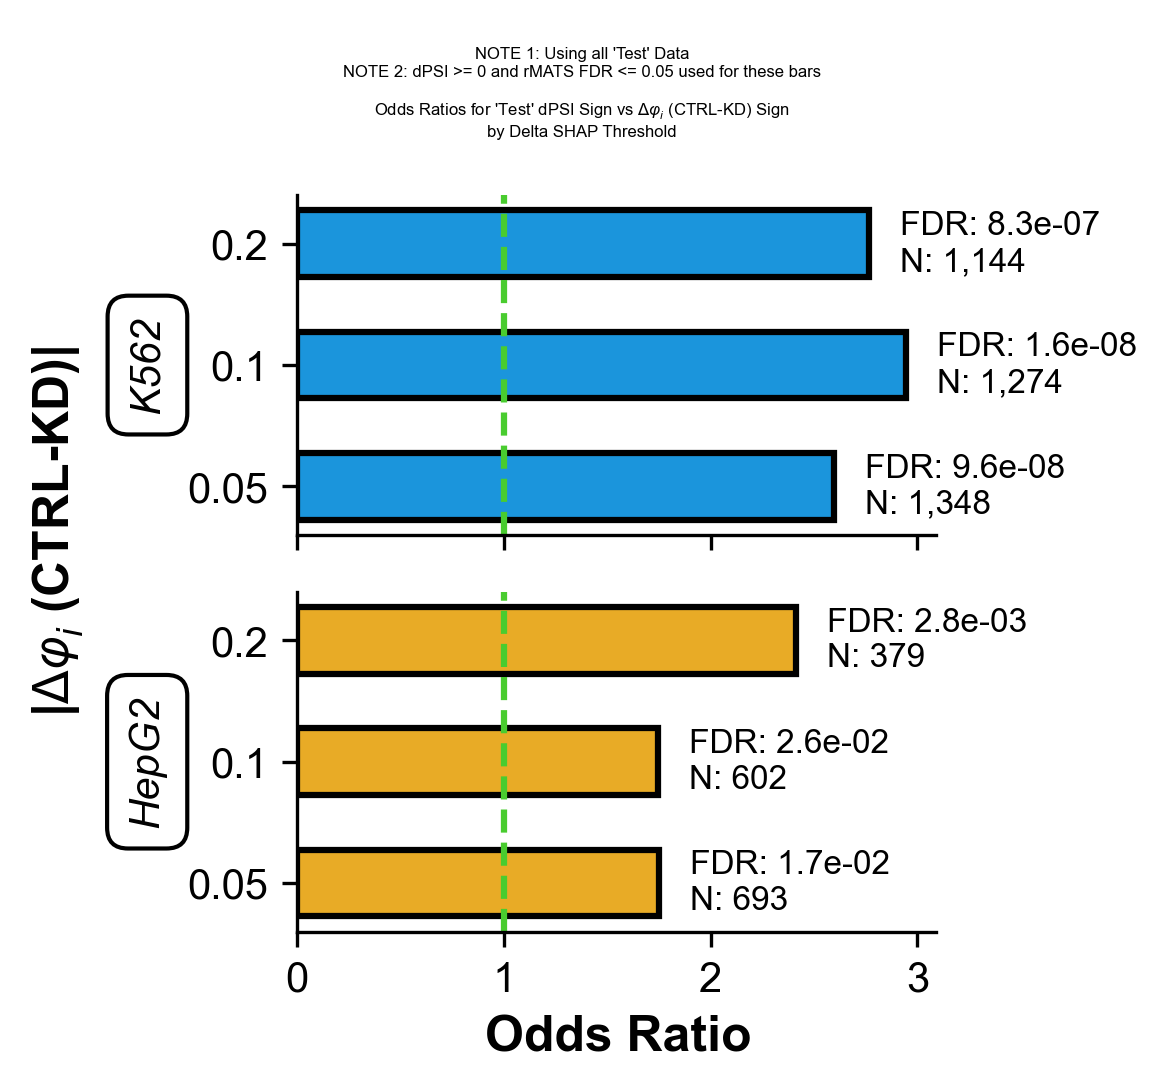

In [2]:
investigator.plot_dpsi_vs_local_SHAP_fishers_test_odds_ratios_as_barplot()